### Mahekdeep Kaur <br>  918042896
___
# Homework 2: Convolutions and Spike Trains
## Due: Tuesday, December 17, 11:59pm

## Part 1: Convolutions

### Math Exercises - Convolutions

The first portion of this homework assignment contains mathematics questions related to the topics covered this week (Convolutions and Filters).
Please write your answers using the Jupyter markup cell’s LaTeX interpreter, or embed a scanned image/pdf of your answers into the markup cell.

More information about LaTeX and Jupyter markdown formatting can be found here:

[https://jupyterbook.org/en/stable/content/math.html](https://jupyterbook.org/en/stable/content/math.html)

And Here:

[https://ashki23.github.io/markdown-latex.html](https://ashki23.github.io/markdown-latex.html)

<a id="question-1"></a>
### Convolving Two Arrays

Given two arrays, $A = [3, 4, 5, 6, 2]$ and $B = [1, 2, 3]$, perform the regular convolution of these arrays. Provide a detailed step-by-step calculation and explain how the convolution changes the characteristics of the original arrays. What is the significance of convolution in signal processing, especially in the context of neural data analysis?

#### Answer
$ A = [3, 4, 5, 6, 2] $ and $ B = [1, 2, 3] $ <br>
The discrete convolution of two arrays $ A $ and $ B $ is calculated as: <br>
$$ C[n] = \sum_{k} A[k] \cdot B[n - k] $$
The length of the resulting convolution is: <br>
$ L = M + N - 1 $ <br>
$ M = 5 $ <br>
$ N = 3 $ <br>
$ L = 5 + 3 - 1 = 7$ <br> <br>
We slide $ B $ over $ A $, calculate element-wise products, and sum them at each position. <br>
1. **Position 0**:
   $ C[0] = (3 \cdot 1) = 3 $
2. **Position 1**:
   $ C[1] = (3 \cdot 2) + (4 \cdot 1) = 6 + 4 = 10 $
3. **Position 2**:
   $ C[2] = (3 \cdot 3) + (4 \cdot 2) + (5 \cdot 1) = 9 + 8 + 5 = 22 $
4. **Position 3**:
   $ C[3] = (4 \cdot 3) + (5 \cdot 2) + (6 \cdot 1) = 12 + 10 + 6 = 28 $
5. **Position 4**:
   $ C[4] = (5 \cdot 3) + (6 \cdot 2) + (2 \cdot 1) = 15 + 12 + 2 = 29 $
6. **Position 5**:
   $ C[5] = (6 \cdot 3) + (2 \cdot 2) = 18 + 4 = 22 $
7. **Position 6**:
   $ C[6] = (2 \cdot 3) = 6 $
   
The resulting convolved array $ C $ is: <br>
$$ C = [3, 10, 22, 28, 29, 22, 6] $$ <br>
Convolution acts like a filter, modifying the signal based on the shape of the second array. The output array length is longer than the original, as the signal expands due to the sliding and summing operation. <br>
- **Filtering**: Convolution modifies signals by applying kernels, which smooth, sharpen, or detect features.
- **Feature Extraction**: It detects patterns in signals, e.g., neural data or images.
- **Signal Transformation**: The convolution combines signals, emphasizing key patterns or responses.
- **Neural Data Analysis**: In neuroscience, convolutions extract firing rates or analyze temporal patterns.


### Convolving Two Signals with an FFT

Consider two discrete-time signals, $X[n]$ and $Y[n]$, each with a length of 1000 points. Write an expression for convolving these signals using the Fast Fourier Transform (FFT) method. Compare the computational complexity of this method with the direct convolution method. Why is FFT-based convolution particularly beneficial in the context of processing large neural datasets?

#### Answer
Given two discrete-time signals $ X[n] $ and $ Y[n] $, each of length $ N = 1000 $, we can convolve these signals efficiently using the **Fast Fourier Transform (FFT)**. <br> 
The convolution of two signals $ X[n] $ and $ Y[n] $ can be computed in the frequency domain as follows: <br>
1. Compute the **FFT** of $ X[n] $ and $ Y[n] $:
   $$ X[k] = \text{FFT}(X[n]), \quad Y[k] = \text{FFT}(Y[n]) $$
   Here, $ X[k] $ and $ Y[k] $ are the frequency-domain representations of $ X[n] $ and $ Y[n] $, respectively.
2. Multiply the frequency-domain representations element-wise:
   $$ Z[k] = X[k] \cdot Y[k] $$
3. Compute the **Inverse FFT (IFFT)** of \( Z[k] \) to obtain the convolved signal:
   $$ Z[n] = \text{IFFT}(Z[k]) $$
   Here, $ Z[n] $ represents the time-domain convolution result.

**Computational Complexity Comparison**
1. **Direct Convolution Method** <br>
The computational complexity of direct convolution for two signals of length $ N $ is: $ O(N^2) $ <br>
Each output sample requires $ N $ multiplications, and there are $ N $ output samples. <br>
For $ N = 1000 $, this results in approximately $ 10^6 $ operations.
2. **FFT-Based Convolution** <br>
The FFT and IFFT each have a computational complexity of $ O(N \log N) $. Computing the convolution using FFT involves: <br>
Two FFTs (one for each signal): $ 2 \cdot O(N \log N) $ <br>
Element-wise multiplication: $ O(N) $ <br>
One IFFT: $ O(N \log N) $ <br>
Thus, the total complexity is:
$ O(N \log N) + O(N) = O(N \log N) $ <br>
For $ N = 1000 $, $ N \log N $ is approximately $ 10^4 $, which is **much faster** than $ 10^6 $ for direct convolution.


The FFT-based convolution is computationally efficient for large signals, reducing the complexity from $ O(N^2) $ to $ O(N \log N) $. This efficiency is particularly beneficial for processing large neural datasets, where computational speed and scalability are critical.

### Moving Average Filter

You have a signal $S = [2, 3, 4, 5, 6, 7, 8, 9, 10]$. Calculate the moving average of this signal using a Finite Impulse Response (FIR) filter with a window size of 3. Show your calculations in detail. Discuss the effect of the moving average filter on the signal, particularly in terms of smoothing and latency. How does this apply to neural signal processing?

#### Answer
The signal $ S $ is: $ S = [2, 3, 4, 5, 6, 7, 8, 9, 10] $ <br>
The window size \( W = 3 \) i.e. we average every three consecutive values. <br>
$$ y[n] = \frac{1}{3}( S[n] + S[n+1] + S[n+2]) $$

1. **At $ n = 0 $:** <br>
   $ y[0] = \frac{1}{3} ( 2 + 3 + 4 ) = \frac{9}{3} = 3 $

2. **At $ n = 1 $:** <br>
   $ y[1] = \frac{1}{3} ( 3 + 4 + 5 ) = \frac{12}{3} = 4 $

3. **At $ n = 2 $:** <br>
   $ y[2] = \frac{1}{3} ( 4 + 5 + 6 ) = \frac{15}{3} = 5 $

4. **At $ n = 3 $:** <br>
   $ y[3] = \frac{1}{3} ( 5 + 6 + 7 ) = \frac{18}{3} = 6 $

5. **At $ n = 4 $:** <br>
   $ y[4] = \frac{1}{3} ( 6 + 7 + 8 ) = \frac{21}{3} = 7 $

6. **At $ n = 5 $:** <br>
   $ y[5] = \frac{1}{3} ( 7 + 8 + 9 ) = \frac{24}{3} = 8 $

7. **At $ n = 6 $:** <br>
   $ y[6] = \frac{1}{3} ( 8 + 9 + 10 ) = \frac{27}{3} = 9 $

The resulting filtered signal $ Y $ is:
$$ Y = [3, 4, 5, 6, 7, 8, 9] $$
**Smoothing:** <br>
The moving average filter smooths the signal by averaging neighboring samples. It reduces short-term fluctuations (high-frequency noise) and highlights the overall trend. <br>
**Latency (Delay):** <br>
The filter introduces a delay because the output depends on the current and future samples within the window. <br>
For a window size $ W = 3 $, the delay is approximately:
  $$ \text{Delay} = \frac{W-1}{2} = 1 \text{ sample.} $$
**Application to Neural Signal Processing:** <br>
- In neural signal processing, moving average filters are used to smooth out noise in time-series data, such as EEG or neural spike trains.
- The trade-off is that while the signal becomes smoother, sharp changes or rapid events might be "blurred" or delayed.


### Programming Exercises

In the following cells, you will write python code to manipulate and analyze an EEG signal, in order to gain insights about what is contained in the signal.

You are provided with 10 EEG recordings containing an ERP. These 10 recordings are in the file named "eeg_signals.pkl". You are also provided with a file called "erp_timestamps.txt", which contain the timestamps for the ERPs in the 10 signals.

You are also provided with an 11th EEG recording, in which you will try to locate the ERP. No timestamp is provided for this recording. This recording is saved in the file called "eeg_signal_to_analyze.pkl".

### Utilize the Convolution Operator From Standard Libraries
Show using Python's `numpy.convolve`
that convolution is a commutative operator.

In [2]:
import numpy as np

# Define two signals
x = [1, 2, 3]
h = [4, 5, 6]

# Compute the convolution in both orders
conv_xh = np.convolve(x, h)  # Convolution of x with h
conv_hx = np.convolve(h, x)  # Convolution of h with x

# Display the results
print("Convolution of x with h:", conv_xh)
print("Convolution of h with x:", conv_hx)

# Check if the two convolutions are equal
if np.array_equal(conv_xh, conv_hx):
    print("Convolution is commutative!")
else:
    print("Convolution is not commutative.")

Convolution of x with h: [ 4 13 28 27 18]
Convolution of h with x: [ 4 13 28 27 18]
Convolution is commutative!


### Write Your Own Convolution Function
Convolve these two signals first with the mentioned functions, and then with your
own code. Write a function that convolves two signals without using any external libraries' built-in convolution function (more general functions such as `np.dot` are permissable).

`x = [1 5 7 9 3 3 3 9 8] ; y = [1 3]`

The convolution should be done in the 'full' mode, meaning that all possible
multiplications of these signals should occur. Remember, The definition of
convolution is: $(x*y)[n] = \sum_{n \in \mathbb{Z}}{x[m] y[m-n]}$. Additionaly,
take note that Matlab flips the second vector that enters the `conv`
function.

In [21]:
import numpy as np

x = [1, 5, 7, 9, 3, 3, 3, 9, 8]
y = [1, 3]
print(np.convolve(x, y))

[ 1  8 22 30 30 12 12 18 35 24]


In [19]:
import numpy as np

x = [1, 5, 7, 9, 3, 3, 3, 9, 8]
y = [1, 3]
#User defined function to calculate convolution
def myConv(x, h):
    len_x = len(x)
    len_h = len(h)
    
    total_length = len_x + len_h - 1
    
    result = np.zeros(total_length)
    
    for i in range(len_x):
        for j in range(len_h):
            result[i + j] += x[i] * h[j]

    return result
print(myConv(x, y))

[ 1.  8. 22. 30. 30. 12. 12. 18. 35. 24.]


<a id="question-5"></a>
### Loading the Data

Write a script to load the 10 EEG recordings located in the "eeg_signals.pkl" file. Once loaded, create visualizations for all of the recordings in both the time and frequency domains. Discuss any notable features you observe in these domains. How do these visualizations help in understanding the EEG recordings?

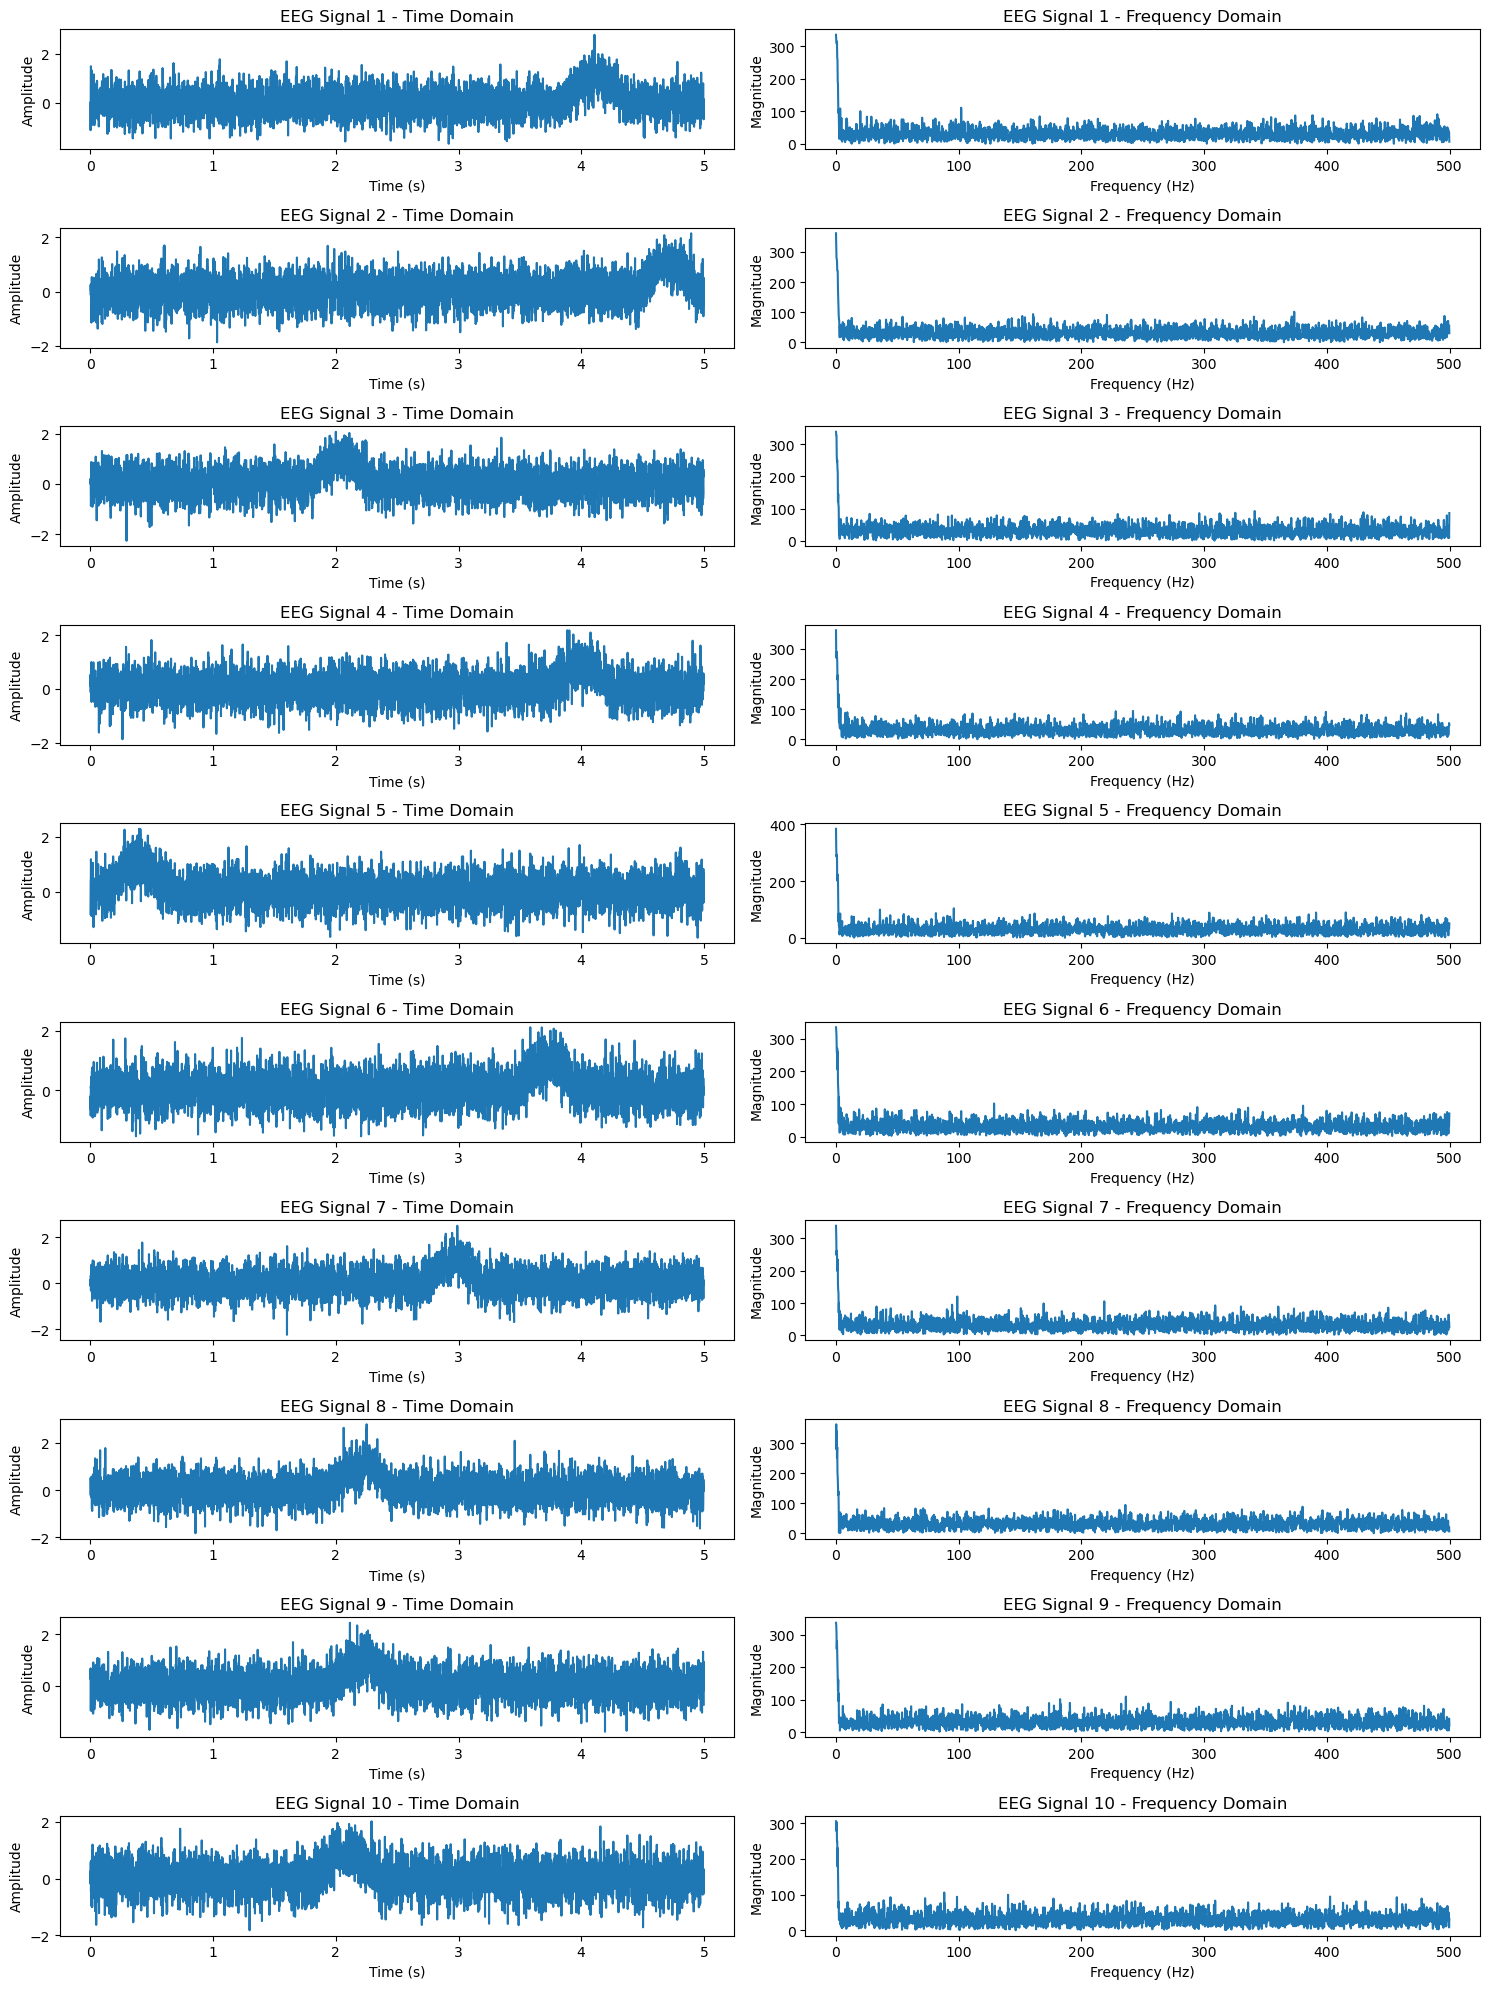

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.fft import fft, fftfreq

# Load EEG signals
with open('eeg_signals.pkl', 'rb') as f:
    eeg_data = pickle.load(f)

# Sampling frequency
Fs = 1000  
N = len(eeg_data[0])  # Length of EEG signal
time = np.arange(0, N) / Fs  # Time vector

# Visualize time and frequency domain for all 10 EEG signals
fig, axes = plt.subplots(10, 2, figsize=(15, 20))

for i, signal in enumerate(eeg_data):
    # Time domain
    axes[i, 0].plot(time, signal)
    axes[i, 0].set_title(f"EEG Signal {i+1} - Time Domain")
    axes[i, 0].set_xlabel("Time (s)")
    axes[i, 0].set_ylabel("Amplitude")

    # Frequency domain
    freq = fftfreq(N, 1 / Fs)
    magnitude = np.abs(fft(signal))[:N // 2]
    axes[i, 1].plot(freq[:N // 2], magnitude)
    axes[i, 1].set_title(f"EEG Signal {i+1} - Frequency Domain")
    axes[i, 1].set_xlabel("Frequency (Hz)")
    axes[i, 1].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

Time-domain visualizations reveal event-related potentials (ERPs), artifacts, and temporal dynamics, helping identify brain responses and anomalies. Frequency-domain visualizations highlight brain rhythms (e.g., delta, theta, alpha) and noise, enabling analysis of spectral content and signal quality.

### Creating ERP Template

Write a script to average the 10 EEG recordings, aligning them based on the known timestamps of the Event-Related Potentials (ERP). This will create an idealized template of the ERP. Plot the resulting averaged ERP and discuss its characteristics. How does averaging help in identifying the features of the ERP? Discuss any potential issues that might arise from this method.


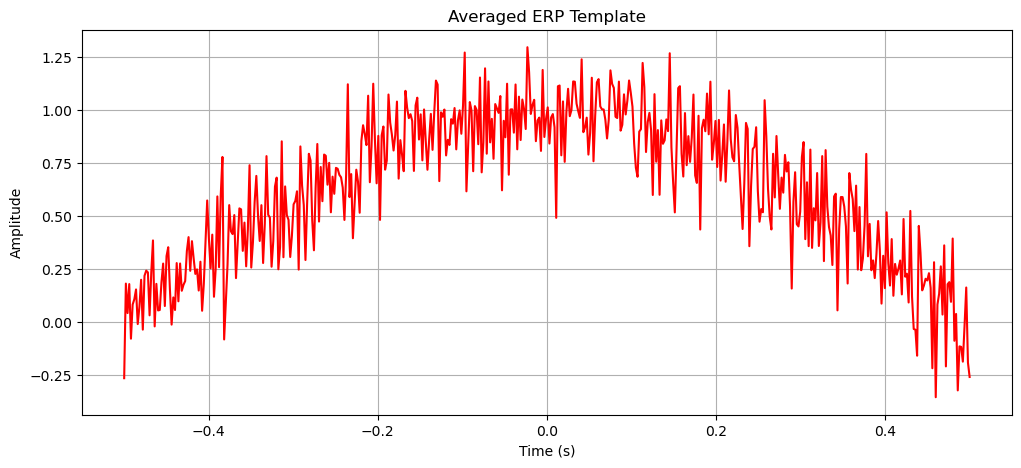

In [49]:
# Load ERP timestamps
with open('erp_timestamps.txt', 'r') as f:
    erp_timestamps = [float(line.strip()) for line in f]
    
# Convert timestamps to sample indices
erp_indices = [int(timestamp * Fs) for timestamp in erp_timestamps]

# Extract ERP segments and average
erp_segments = []
window = int(0.25 * Fs) 

for i, signal in enumerate(eeg_data):
    start = erp_indices[i] 
    end = erp_indices[i] + 2*window
    erp_segments.append(signal[start:end])

erp_template = np.mean(erp_segments, axis=0)

# Plot ERP template
time_window = np.linspace(-0.5, 0.5, 2 * window)

plt.figure(figsize=(12, 5))
plt.plot(time_window, erp_template, color='red')
plt.title("Averaged ERP Template")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Averaging enhances ERP features by reducing random noise and emphasizing consistent, time-locked responses across trials, improving the signal-to-noise ratio (SNR). However, issues may arise if ERP signals are misaligned, if there’s high inter-trial variability, or if artifacts distort the averaged signal.

<a id="question-8"></a>
### Matched Filter Convolution

Use the ERP template created in the previous question to perform a matched filter convolution with the new EEG recording (the one where the ERP location is unknown). Write a script that implements this convolution and identify where in the recording the ERP is most likely to occur. Provide a plot showing the convolution output and indicate the location of the ERP. Discuss how the matched filter approach helps in detecting the ERP and any limitations or challenges of this method.

**Use your convolution function from the previous steps**

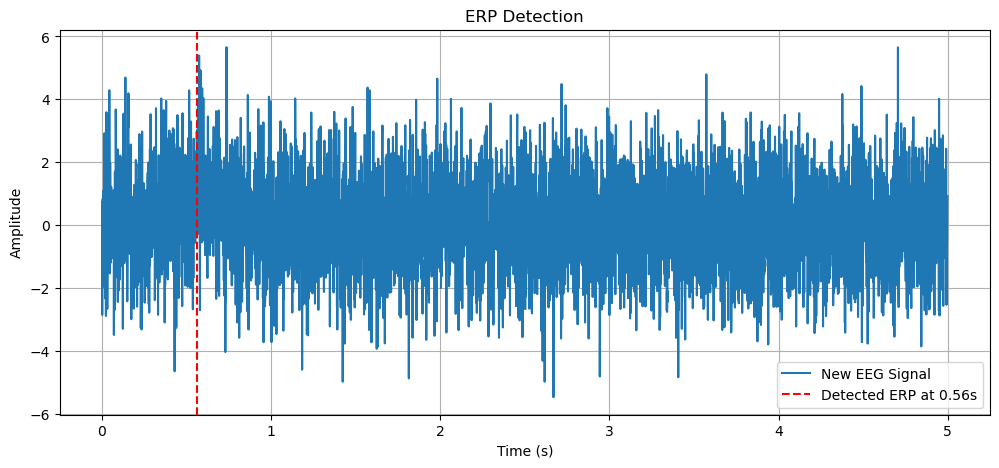

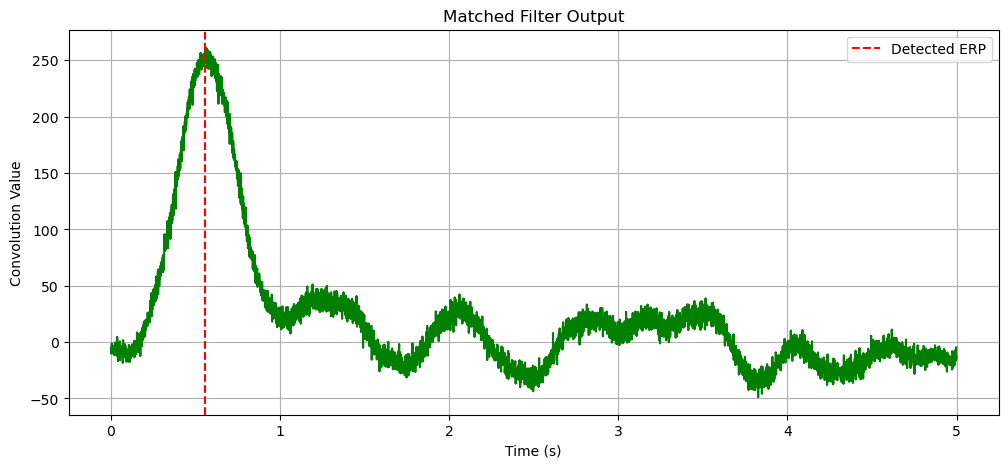

In [44]:
# Load the unknown EEG signal
with open('eeg_signal_to_analyze.pkl', 'rb') as f:
    new_eeg_signal = pickle.load(f)

# Perform convolution using the ERP template
matched_filter_output = np.convolve(new_eeg_signal, erp_template, mode='same')

# Find ERP location
erp_location = np.argmax(matched_filter_output)
time_erp = erp_location / Fs  # Convert to seconds

# Plot the convolution output
plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(new_eeg_signal)) / Fs, new_eeg_signal, label="New EEG Signal")
plt.axvline(time_erp, color='r', linestyle='--', label=f"Detected ERP at {time_erp:.2f}s")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("ERP Detection")
plt.legend()
plt.grid()
plt.show()

# Plot matched filter output
plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(matched_filter_output)) / Fs, matched_filter_output, color='green')
plt.axvline(time_erp, color='r', linestyle='--', label="Detected ERP")
plt.title("Matched Filter Output")
plt.xlabel("Time (s)")
plt.ylabel("Convolution Value")
plt.legend()
plt.grid()
plt.show()

The matched filter approach detects ERPs by maximizing the signal-to-noise ratio (SNR) through convolution with an ERP template, highlighting regions in the EEG signal that match the template. It is optimal for identifying weak, time-locked signals in noisy data. However, limitations include sensitivity to template accuracy, misalignment errors, and the possibility of false positives in the presence of noise or overlapping events.

## Part 2: Poisson Spike Trains

In this question we'll create and work with a spike train. The idea is to create a set of functions that can be used for your spike train analysis pipeline. These function should be reusable. The functions or modules you should define are:

- `readPoiSpikes`
- `generatePoiSpikes`
- `calcFF`
- `calcCV`
- `alcRate`

In this week's directory in the GitRepo,  there are two spiketrain datasets named `rawSpikes1.mat` and `rawSpikes2.mat`. They both should be placed into 1 ms bins. The spike times there are in milliseconds.

**Write each function inside a jupyter code cell or python file. Upload a PDF to your gitrepo of the outputs of each of your functions for both the provided spike trains and the one you generate.

Use the following parameters to test out your code:

```python
r = 94 #spikes per second
Fs = 1e3 #Sampling frequency
totalTime = 30 #seconds
dt = 0.001 #seconds
binSize = 0.01 #seconds
```

#### Load Data

Write a function that loads a dataset in the format of the spike train files in this gitrepo and outputs it as a spike train with a set binwidth. The function has to be able to read both column and row vectors, and should be robust to empty datasets.

```python
def readPoiSpikes(fileName, Fs):

    data = loadmat(fileName)
    rawspike = np.array(data['spikes'])
    rawspike = rawspike.flatten()
    
    totalTime = int(np.max(rawspike))
    
    if rawspike.size == 0:
        raise ValueError("Empty file")
    
    spikeBins = np.arange(0,totalTime+1,1) #bins in ms
    spikeTrain,_= np.histogram(rawspike, bins=spikeBins)
    spikeTrain = (spikeTrain>0).astype(int)
    
    return spikeTrain
```

#### Generate Spike Trains

Write a function that generates a spike train, according to the Poisson process model and the explanation that was given in the exercise, under the "Poisson Generator" section. This function should run only if we didn't load a spike train earlier (don't just comment out the previous function). Here we assume $r(t)=r$ and
$P(\text{spike occurred}) = r\Delta t$ for short $\Delta t$. That means that we're considering a homogeneous process in this case. Make sure all operations are done in a vectorized manner, no loops!

```python
def generatePoiSpikes(r, dt, totalSize):

    p = r*dt
    rand = np.random.rand(totalSize)
    spikeTrain = np.zeros(totalSize)
    spikeTrain = (rand<p).astype(int)

    return spikeTrain
```

#### Fano Factor and Coefficient of Variation

After we have a spike train at hand, we want to check whether the spikes are indeed Poisson-distributed. The two ways to check it were discussed in class: the Fano Factor and Coefficient of Variation. Write two functions that check these parameters for the spike trains.

Calculate the CV and FF of the two given spike trains and the one you generated. Consider carefully how to calculate the FF of a **single** spike train.

```python
def calcCV(spikeTrain):

    spikeIndices = np.where(spikeTrain == 1)[0]
    isi = np.diff(spikeIndices)  
    
    if len(isi) < 2:
        return np.nan  # Return NaN if there aren't enough spikes to calculate CV
    
    CV = np.std(isi) / np.mean(isi)
    
    return CV
```


```python
def calcFF(spikeTrain):

    FF = np.var(spikeTrain) / np.mean(spikeTrain) if np.mean(spikeTrain) > 0 else np.nan
    
    return FF
```

#### Rate of fire

Lastly we'll check the rate of fire of our neurons. The function should receive a spike train and length of the window in which it should calculate the rate. Length = 0 means that it should just return the average rate of fire of the whole train. A different window requires you to calculate the firing rate in that window, and plot the results over time - $r(t)$. Make sure the function is robust for all types of inputs. Calculate the rate of fire for the two given spike trains and the one you generated

```Python
def calcRate(spikeTrain, window, dt):

    binWidth = int(window / dt) if window > 0 else len(spikeTrain)
    rateOfFire = [
        np.sum(spikeTrain[i:i+binWidth]) / (binWidth * dt)
        for i in range(0, len(spikeTrain), binWidth)
    ]
    
    if window > 0:
        timeBins = np.arange(0, len(rateOfFire)) * window
        plt.figure(figsize=(12, 3))
        plt.plot(timeBins, rateOfFire)
        plt.xlabel('Time (s)')
        plt.ylabel('Rate of Fire (Hz)')
        plt.title(f'Firing Rate over Time, Window: {window} s')
        plt.grid()
        plt.show()
    
    return rateOfFire
```